In [2]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
import scipy as sp
from copy import deepcopy 
from tqdm import tqdm
import os
import sys
sys.path.append(os.path.abspath(".."))

from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix
from bbhx.waveformbuild import BBHWaveformFD

# Immports for generating simulated LISA data
import noise_generation as noise_generation
from tools.LISASimulator import LISASimulator
from tools.likelihood import get_dh, get_hh
import tools.likelihood as likelihood

# Imports for MCMC
from tools.time_freq_likelihood import TimeFreqLikelihood
from eryn.ensemble import EnsembleSampler
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State

# Imports for plotting
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd
gpu = False
if gpu:
    import cupy as cp
else:
    import numpy as cp

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.


# Noise Plot

In [3]:
HOUR_SI = 3600
DAY_SI = 24*60*60
Tobs = 1.2*YRSID_SI/12  # Total observation time in seconds
dt = 5.
include_T_channel = False # Set to True if you want to include the T channel in the simulation, otherwise only A and E channels will be included.

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=gpu)
sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 3e5
m2 = 1.5e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0
lam = 0*(np.pi/180)
beta = 90*(np.pi/180)
psi = 0
t_ref = Tobs - (24*60*60) 
parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

print(sim.SNR_optimal()[0])

hours_before_merger = 100
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60

def pre_merger(gravitational_wave_data_t, time_before_merger, t_ref, t_array):
        cutoff_time = t_ref - time_before_merger
        cutoff_index = np.searchsorted(t_array, cutoff_time)
        data_t_truncated = gravitational_wave_data_t[:, :cutoff_index]
        return data_t_truncated, cutoff_index

data_t_truncated,   cutoff_index =  pre_merger(data_t, time_before_merger, t_ref, t_array)
signal_t_truncated, cutoff_index =  pre_merger(sim.signal_t[0], time_before_merger, t_ref, t_array)

1743.4321506687259


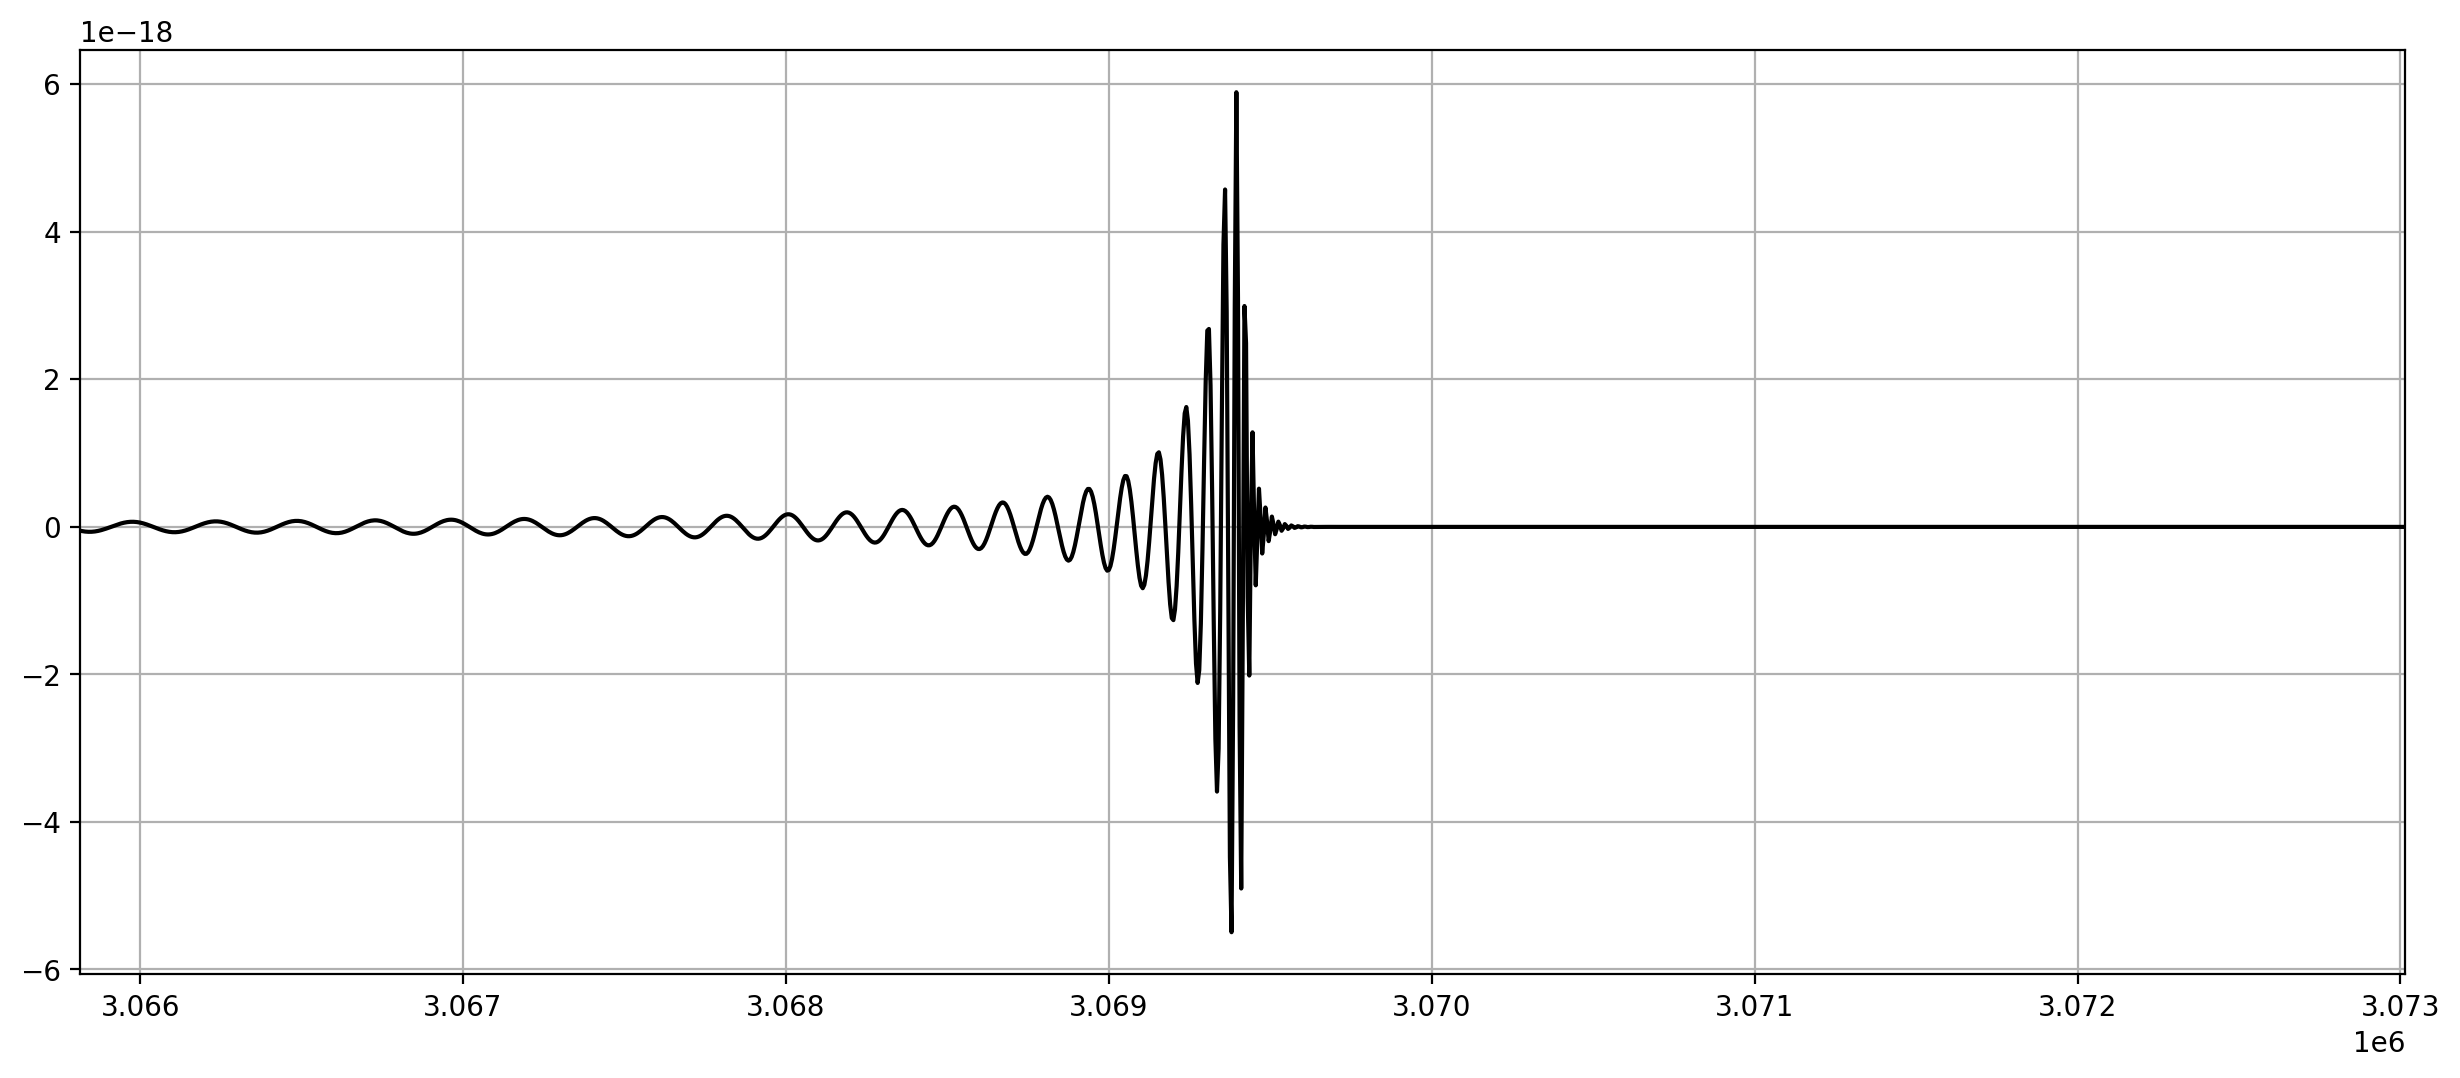

In [8]:
plt.figure(figsize=(15,6))
plt.plot(t_array, sim.signal_t[0,0], color='k')
plt.xlim(t_ref - 1*HOUR_SI, t_ref + 1*HOUR_SI)
plt.grid(True)
#plt.axvline(t_ref)
#plt.axvline(cutoff_time)
#plt.axvline(max_time)

(618,) (1401,)


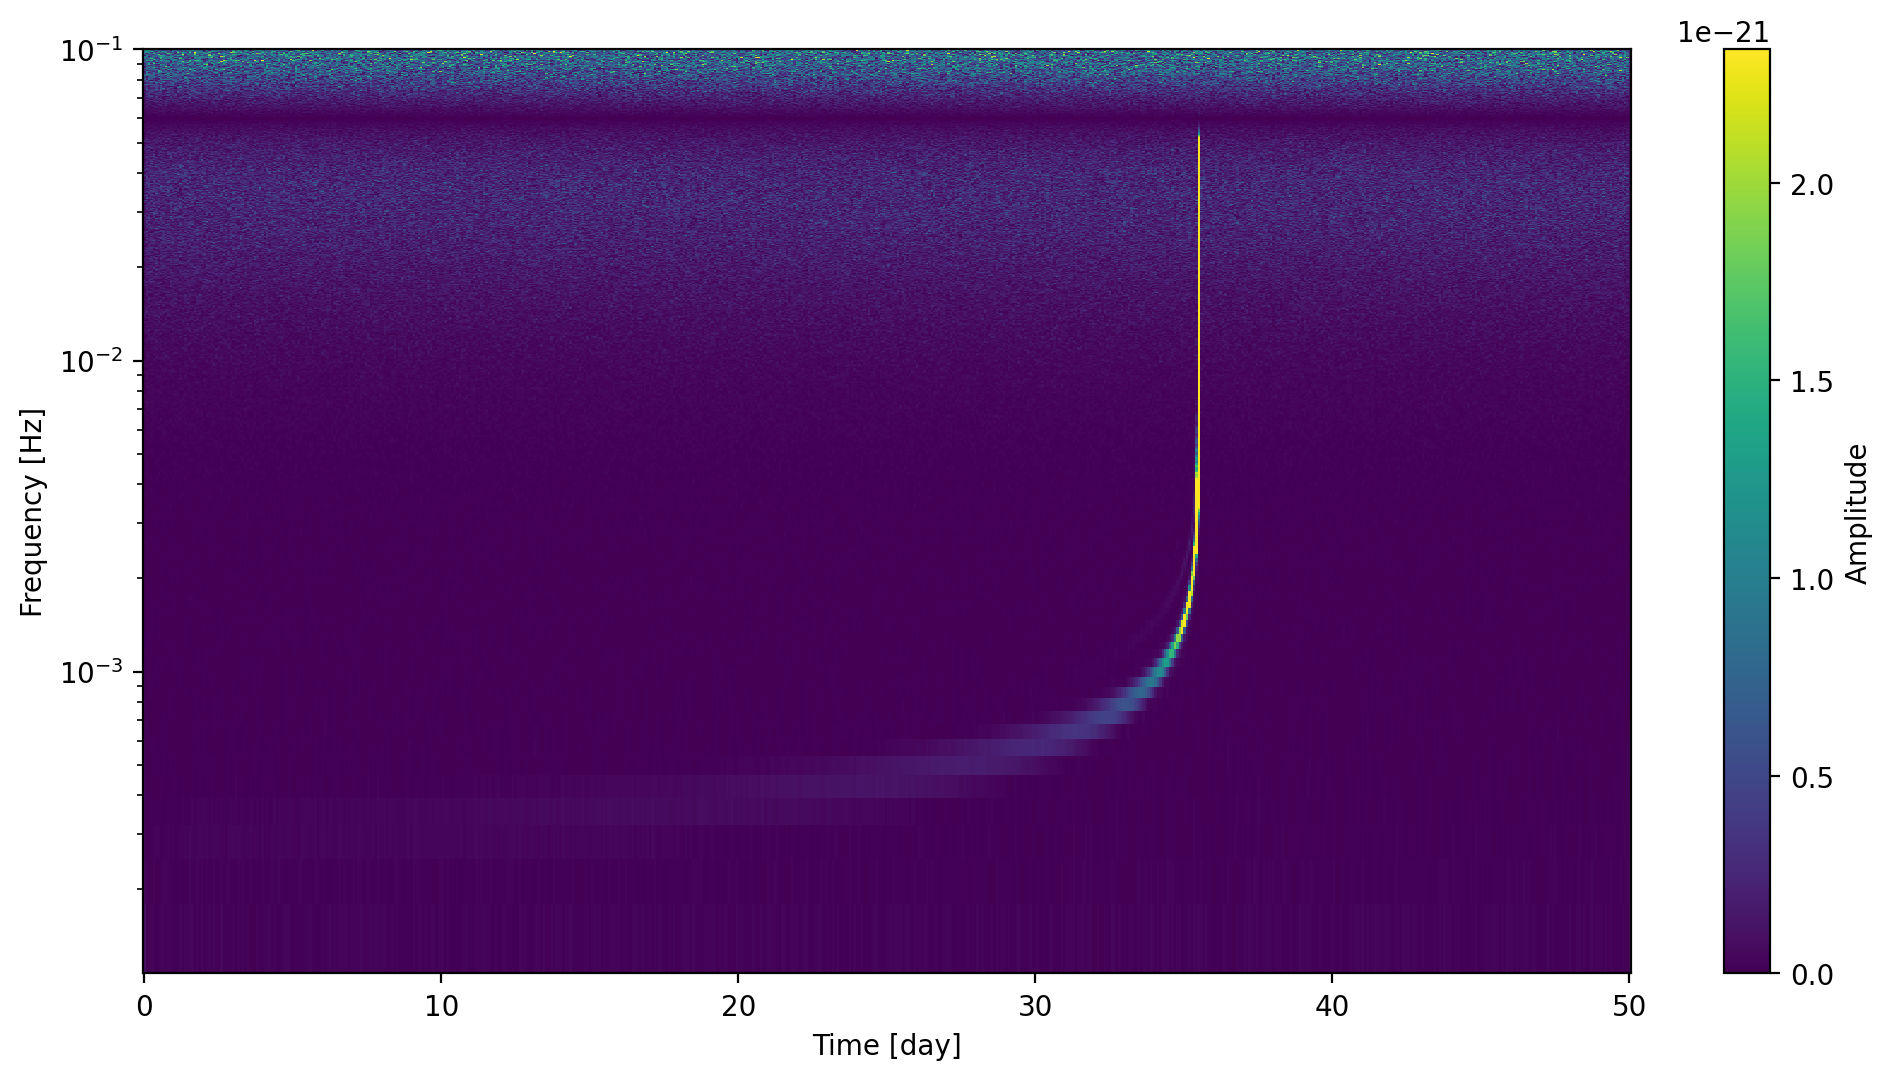

In [89]:
f, t, Zxx = sp.signal.stft(data_t[0], fs=1/sim.dt, nperseg=2801)#, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 1e-1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 6))
plt.pcolormesh(t/(3600*24), f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
#plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [day]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
cbar = plt.colorbar()
cbar.set_label("Amplitude") 


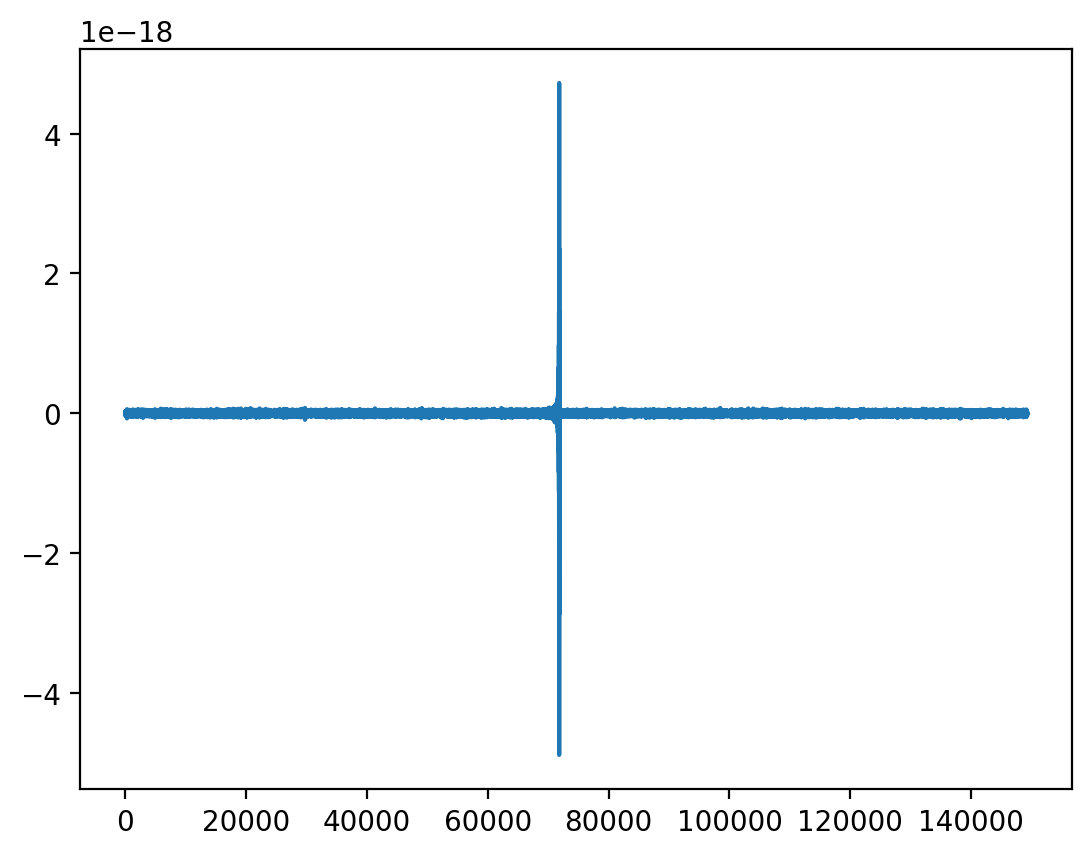

In [76]:
def post_observation(gravitational_wave_data_t, t_array, cutoff_index):
        data_t_post_observation = gravitational_wave_data_t[:, cutoff_index:]
        t_array_post_observation = t_array[cutoff_index:]

        return data_t_post_observation, t_array_post_observation

data_t_post_observation, t_array_post_observation =  post_observation(data_t, t_array, cutoff_index)
plt.plot(data_t_post_observation[0])

(151,) (501,)


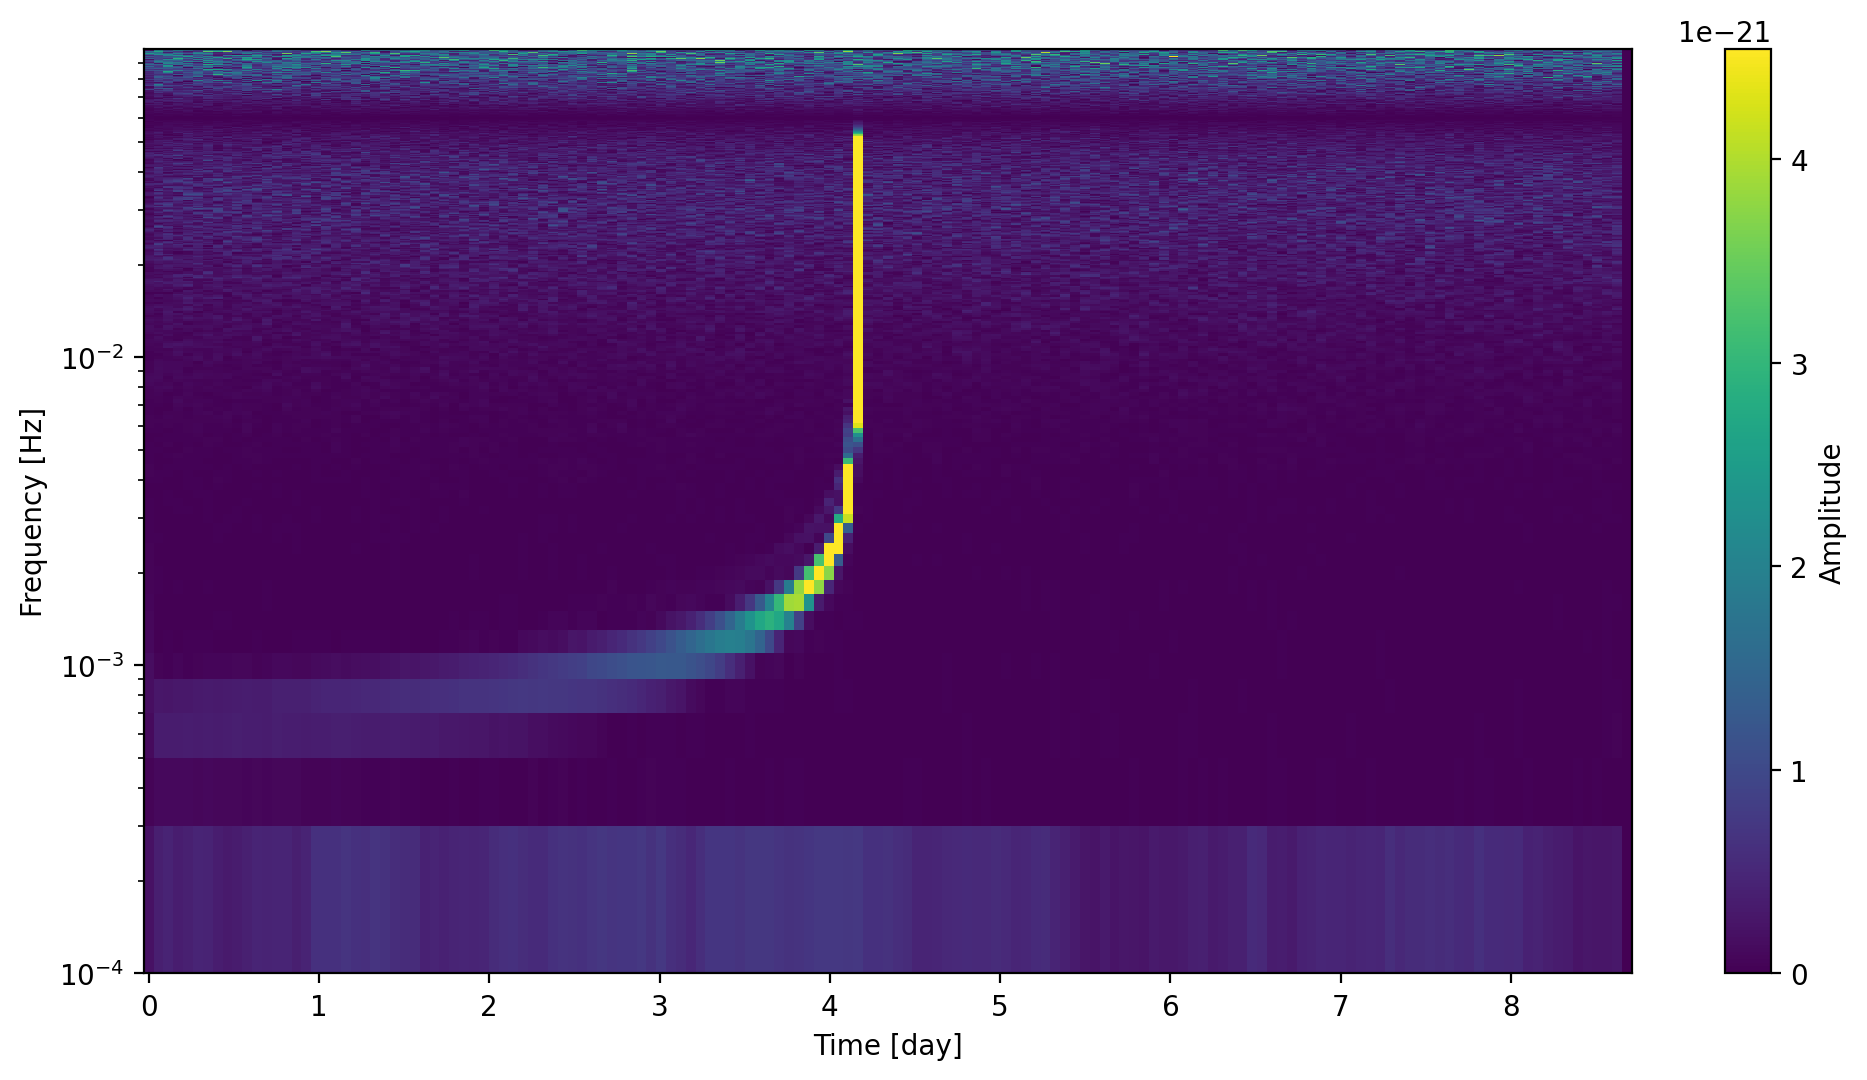

In [77]:
f, t, Zxx = sp.signal.stft(data_t_post_observation[0], fs=1/sim.dt, nperseg=1000, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 1e-1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 6))
plt.pcolormesh(t/(3600*24), f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
#plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [day]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
cbar = plt.colorbar()
cbar.set_label("Amplitude") 


In [ ]:
2082 // 2

In [ ]:
f, t, Zxx = sp.signal.stft(data_t[0], fs=1/sim.dt, nperseg=2081, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 0.01)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
plt.colorbar()

# Presentation Plots

In [ ]:
from tools.likelihood import TimeFreqSNR
analysis = TimeFreqSNR(
    data_t=data_t_truncated,
    wave_gen=wave_gen,
    nperseg=1414,
    dt_full=dt,
    cutoff_index=cutoff_index,
    pre_merger=True
)
analysis.get_stft_of_data()
SNR, amplitude = analysis.calculate_time_frequency_SNR(*parameters, waveform_kwargs=waveform_kwargs)
new_distance = dist /  amplitude
print((new_distance - dist)/(PC_SI*1e9) , (new_distance-dist)/dist)
print( "True distance       = ",  dist/(PC_SI*1e9), "Gpc")
print( "Dist from Amplitude = ",  new_distance/(PC_SI*1e9), "Gpc")
print( "SNR calculated      = ",  SNR)

In [ ]:
f, t, Zxx = sp.signal.stft(data_t_truncated[0], fs=1/sim.dt, nperseg=2081, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
plt.colorbar()

In [ ]:
max_index = np.argmax(wave_full)
print("Index of max value in wave_truc:", max_index)

In [ ]:
wave_full = sim.signal_t[0,0]
max_index = np.argmax(wave_full)
delta_left = 2000
delta_right = 1500
wave_truc = wave_full[max_index-delta_left:max_index+delta_right]
split_index = 800
wave_truc_part_1 = wave_truc.copy()
wave_truc_part_1[split_index:] = np.nan
wave_truc_part_2 = wave_truc.copy()
wave_truc_part_2[:split_index] = np.nan
tarray_truncated = np.arange(len(wave_truc)) 
max_index_truc = np.argmax(wave_truc)
delta_trunc = 800
plt.figure(figsize=(12, 5))
plt.plot(tarray_truncated, wave_truc_part_1, color='black', alpha=0.5)
plt.plot(tarray_truncated, wave_truc_part_2, color='black', alpha=1)
plt.xlim(0, len(wave_truc))
plt.axvline(max_index_truc-delta_trunc)
plt.axvline(max_index_truc+delta_trunc)